[[130. 132. 129. ... 110. 111. 109.]
 [130. 132. 129. ... 113. 111. 109.]
 [128. 134. 131. ... 115. 109. 109.]
 ...
 [ 40.  37.  38. ...  59.  57.  53.]
 [ 38.  38.  37. ...  61.  57.  57.]
 [ 38.  38.  39. ...  76.  70.  65.]]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


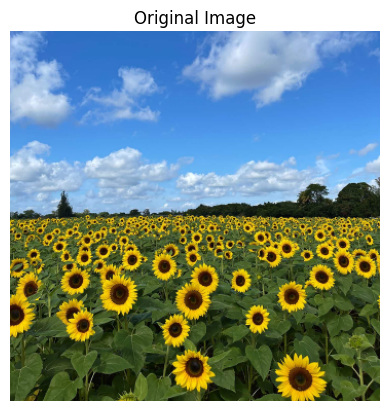

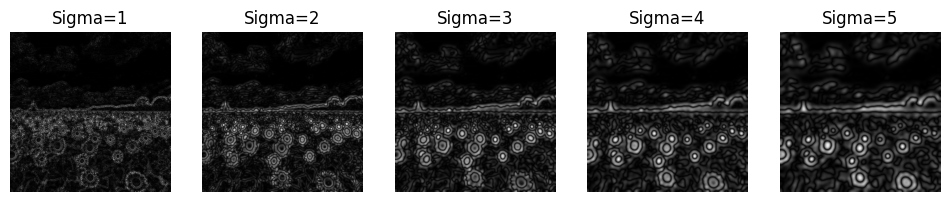

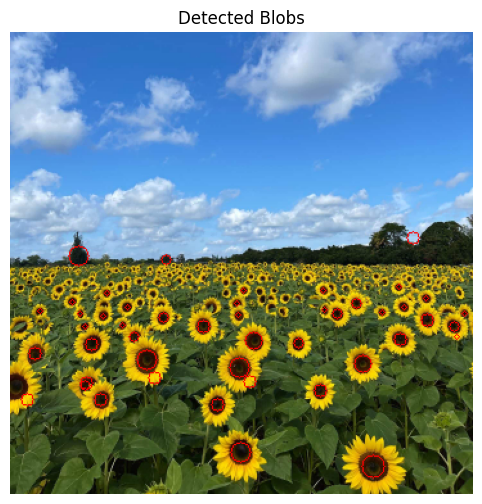

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

im = cv.imread('images/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_copy = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

print(im_copy.astype(np.float32))
im_copy = im_copy.astype(np.float32) / 255.0

fig, ax = plt.subplots()
original = cv.cvtColor(im, cv.COLOR_BGR2RGB)
ax.imshow(original)
ax.set_title('Original Image')
ax.axis('off')

logArray = []
sigmaArray = []

for i in range(1, 16):
# Create 1D Gaussian kernel
    sigma = i
    ksize = round(6*sigma + 1)  # should be odd
    g1d = cv.getGaussianKernel(ksize, sigma)

    # Make 2D Gaussian kernel by outer product
    g2d = g1d @ g1d.T   # equivalent to np.outer(g1d, g1d)

    # Normalize to make sure kernel sums to 1
    g2d = g2d / g2d.sum()

    # Convolve image with your Gaussian kernel
    filtered = cv.filter2D(im_copy, ddepth=-1, kernel=g2d)

    # Get the laplacian of the image
    log = cv.Laplacian(filtered, ddepth=cv.CV_32F)

    log = (sigma**2) * np.abs(log)  

    logArray.append(log)
    sigmaArray.append(sigma)

print(sigmaArray)

extremas = []

for i in range(1, len(logArray)-1):
    for j in range(1, len(logArray[i])-1):
        for k in range(1, len(logArray[i][j])-1):
            if logArray[i][j][k] > logArray[i][j-1][k-1] and logArray[i][j][k] > logArray[i][j][k-1] and logArray[i][j][k] > logArray[i][j+1][k-1] and logArray[i][j][k] > logArray[i][j-1][k] and logArray[i][j][k] > logArray[i][j+1][k] and logArray[i][j][k] > logArray[i][j-1][k+1] and logArray[i][j][k] > logArray[i][j][k+1] and logArray[i][j][k] > logArray[i][j+1][k+1]:
                if logArray[i][j][k] > logArray[i+1][j-1][k-1] and logArray[i][j][k] > logArray[i+1][j][k-1] and logArray[i][j][k] > logArray[i+1][j+1][k-1] and logArray[i][j][k] > logArray[i+1][j][k] and logArray[i][j][k] > logArray[i+1][j-1][k] and logArray[i][j][k] > logArray[i+1][j+1][k] and logArray[i][j][k] > logArray[i+1][j-1][k+1] and logArray[i][j][k] > logArray[i+1][j][k+1] and logArray[i][j][k] > logArray[i+1][j+1][k+1]:
                    if logArray[i][j][k] > logArray[i-1][j-1][k-1] and logArray[i][j][k] > logArray[i-1][j][k-1] and logArray[i][j][k] > logArray[i-1][j+1][k-1] and logArray[i][j][k] > logArray[i-1][j][k] and logArray[i][j][k] > logArray[i-1][j-1][k] and logArray[i][j][k] > logArray[i-1][j+1][k] and logArray[i][j][k] > logArray[i-1][j-1][k+1] and logArray[i][j][k] > logArray[i-1][j][k+1] and logArray[i][j][k] > logArray[i-1][j+1][k+1]:
                        if logArray[i][j][k] > 0.275:  # Threshold to filter weak responses
                            extremas.append((i, j, k))


for (s, x, y) in extremas:
    # Convert to int for drawing
    center = (int(y), int(x))
    radius = int(sigmaArray[s] * np.sqrt(2))  # commonly used
    color = (0, 0, 255)  # red circle
    thickness = 1
    cv.circle(im, center, radius, color, thickness)


fig, ax = plt.subplots(1,5, figsize=(12, 6))
ax[0].imshow(logArray[0], cmap='gray')
ax[1].imshow(logArray[1], cmap='gray')
ax[2].imshow(logArray[2], cmap='gray')
ax[3].imshow(logArray[3], cmap='gray')
ax[4].imshow(logArray[4], cmap='gray')
ax[0].set_title('Sigma=1')
ax[1].set_title('Sigma=2')
ax[2].set_title('Sigma=3')
ax[3].set_title('Sigma=4')
ax[4].set_title('Sigma=5')
for a in ax:
    a.axis('off')   


fig, ax = plt.subplots(1,1, figsize=(12, 6))
output = cv.cvtColor(im, cv.COLOR_RGB2BGR)  # Convert to BGR for colored circles
ax.imshow(output)
ax.set_title('Detected Blobs')
ax.axis('off')

plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Found blobs: 62


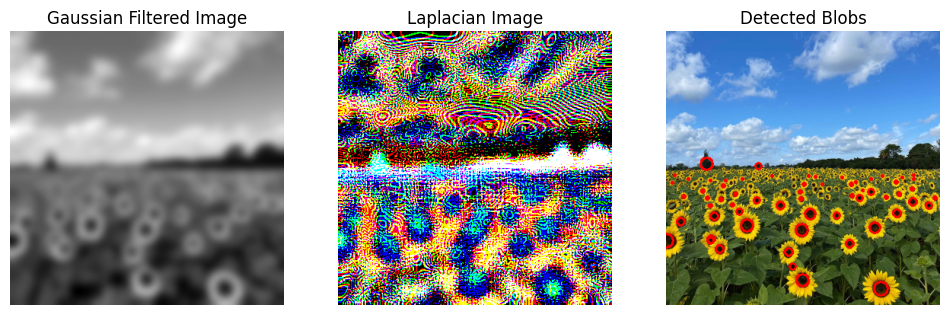

In [ ]:
import numpy as np
import cv2 as cv
from scipy.ndimage import maximum_filter

im = cv.imread('images/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

# assume im is float32 in [0,1] or uint8 (we'll convert)
im_gray = im.copy()
if im_gray.dtype != np.float32:
    im_gray = im_gray.astype(np.float32) / 255.0

sigmas = list(range(1, 16))   # your sigma values
log_responses = []

for sigma in sigmas:
    # kernel size: cover ~6*sigma and force odd
    ksize = int(round(6 * sigma + 1))
    if ksize % 2 == 0:
        ksize += 1

    g1d = cv.getGaussianKernel(ksize, sigma)
    g2d = g1d @ g1d.T
    g2d = g2d / g2d.sum()

    blurred = cv.filter2D(im_gray, ddepth=cv.CV_32F, kernel=g2d)
    lap = cv.Laplacian(blurred, ddepth=cv.CV_32F)   # signed
    response = (sigma**2) * lap           # scale-normalized absolute LoG
    log_responses.append(response)

# Stack into (S, H, W)
scale_space = np.stack(log_responses, axis=0)

# 3D non-maximum suppression using a 3x3x3 max filter
footprint = np.ones((3, 3, 3), dtype=bool)
local_max = (scale_space == maximum_filter(scale_space, footprint=footprint))

# Threshold: relative to global max or choose percentile
global_max = scale_space.max()
threshold = 0.7 * global_max   # tune this
candidates = np.where(local_max & (scale_space >= threshold))

s_idxs, ys, xs = candidates
blobs = []
for s, y, x in zip(s_idxs, ys, xs):
    sigma = sigmas[s]
    radius = int(np.sqrt(2) * sigma)
    blobs.append((int(x), int(y), radius, sigma, scale_space[s, y, x]))

print("Found blobs:", len(blobs))
# blobs entries: (x, y, radius, sigma, response_value)

for (x, y, radius, sigma, response_value) in blobs:
    # Convert to int for drawing
    center = (int(x), int(y))
    color = (0, 0, 255)  # red circle
    thickness = 2
    cv.circle(im1, center, radius, color, thickness)


fig, ax = plt.subplots(1,3, figsize=(12, 6))
ax[0].imshow(filtered, cmap='gray')
ax[0].set_title('Gaussian Filtered Image')
ax[0].axis('off')

ax[1].imshow(log, cmap='gray')
ax[1].set_title('Laplacian Image')
ax[1].axis('off')

im = cv.cvtColor(im1, cv.COLOR_BGR2RGB)  # Convert to RGB for displaying with matplotlib
ax[2].imshow(im)
ax[2].set_title('Detected Blobs')
ax[2].axis('off')  

plt.show()



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


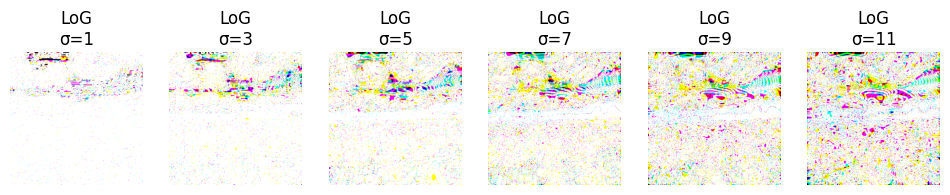

In [50]:
sigmas = [1, 3, 5, 7, 9, 11]
logs = []

for sigma in sigmas:
    blur = cv.GaussianBlur(im, (0, 0), sigma) 
    log = cv.Laplacian(blur, cv.CV_32F, ksize=5)
    log_norm = sigma**2 * np.abs(log) #cause we want to scale and casue we just want blobs, not bright or dark
    logs.append(log_norm)

fig, ax = plt.subplots(1, 6, figsize=(12, 4))
for i in range(6):
    ax[i].imshow(logs[i], cmap='gray')
    ax[i].set_title(f'LoG\nσ={sigmas[i]}')
    ax[i].axis('off')
plt.show()

In [ ]:
from skimage.feature import peak_local_max

# Find local maxima in 3D scale space
coordinates = peak_local_max(scale_space, threshold_abs=0.03, footprint=np.ones((7,7,3)))

# Extract parameters
blobs = []
for y, x, s in coordinates:
    sigma = sigmas[s]
    r = np.sqrt(2) * sigma
    blobs.append((x, y, r))

# Sort by radius to get the largest blobs
blobs = sorted(blobs, key=lambda b: b[2], reverse=True)
largest_blobs = blobs[:5]  # report top 5

# Draw detected circles
output = im.copy()
for (x, y, r) in blobs:
    cv.circle(output, (int(x), int(y)), int(r), (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Detected Sunflower Blobs")
plt.axis("off")
plt.show()

# Print largest circles' parameters
print("Range of sigma values used:", sigma_values)
print("Top 5 largest circles (x, y, radius):")
for b in largest_blobs:
    print(b)

In [15]:
%pip install tikzplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


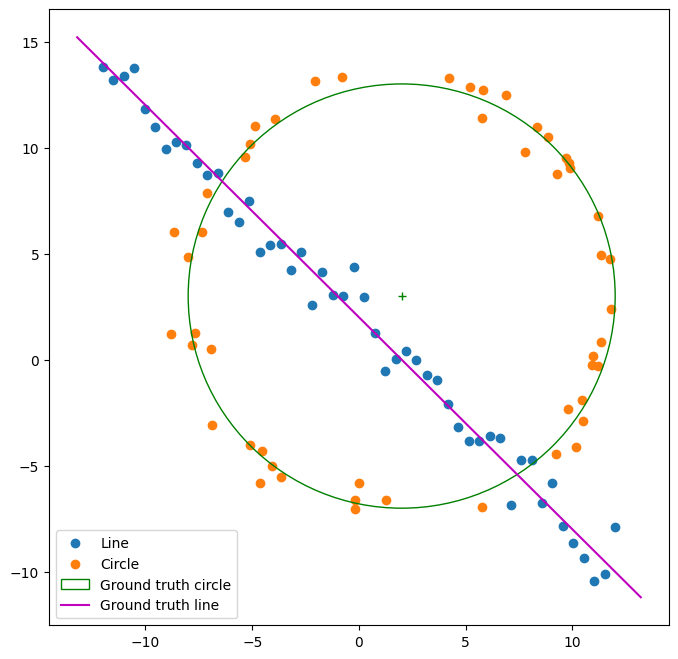

In [44]:
# Generation of a Noisy Point Set Conforming to a Line and a Circle
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
# import tikzplotlib

# np.random.seed(0)

N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Center

# Generate noisy circle points
s = r / 16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Generate noisy line points
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Combine all points
X = np.vstack((X_circ, X_line))  # All points

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')

circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)

ax.plot(x0_gt, y0_gt, '+', color='g')

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')

plt.legend()
plt.show()


In [36]:
print(len(X_line))
print(len(X))

50
50


In [37]:
def compute_line(p1, p2):
    a = p1[1] - p2[1]
    b = p2[0] - p1[0]

    #Step 3: compute c
    c = -(a * p1[0] + b * p1[1])

    # Step 4: normalize
    norm = np.sqrt(a**2 + b**2)
    a /= norm
    b /= norm
    c /= norm

    return a, b, c

def compute_error(line, point):
    a, b, c = line
    dist = np.abs(a * point[0] + b * point[1] + c)
    return dist

0 9
1 16
2 12
3 12
4 14
5 43
6 9
7 12
8 15
9 25
10 18
11 11
12 10
13 11
Best line found with points: 0.7042709364143509x + 0.7099312981705013b + -1.2248384617634436 giving 48 inliers


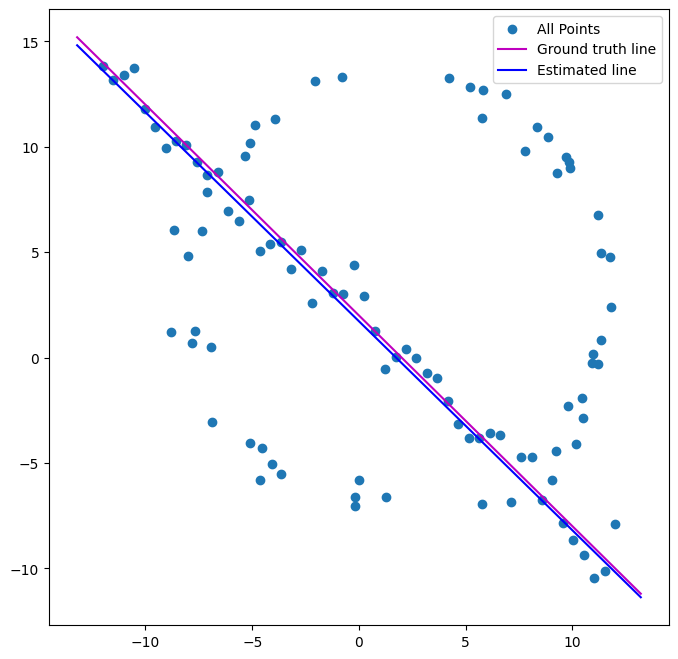

In [134]:
def RANSAC_line(X, N):
    for i in range(N): #decided to go with 17 from the equation with 0.99 probability
        count = 0
        inliers = []
        idx = np.random.choice(X.shape[0], size=2, replace=False)
        line = compute_line(X[idx][0], X[idx][1])
        for id, point in enumerate(X):
            error = compute_error(line, point)
            if error < 1.4: #threshold decided from the 1.96*sigma in line points
                inliers.append(id)
                count += 1
        if count >= 47: #95% of line points
            return line, count, inliers, idx
        print(i, count)

# Run RANSAC to find the best line
best_line, count_line, inliers_line, idx_line = RANSAC_line(X, 17)
print(f"Best line found with points: {best_line[0]}x + {best_line[1]}b + {best_line[2]} giving {count} inliers")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], label='All Points')
ax.plot(x_, m * x_ + b, color='m', label='Ground truth line')
ax.plot(x_, -(best_line[0] * x_ + best_line[2]) / best_line[1], color='b', label='Estimated line')
plt.legend()
plt.show()

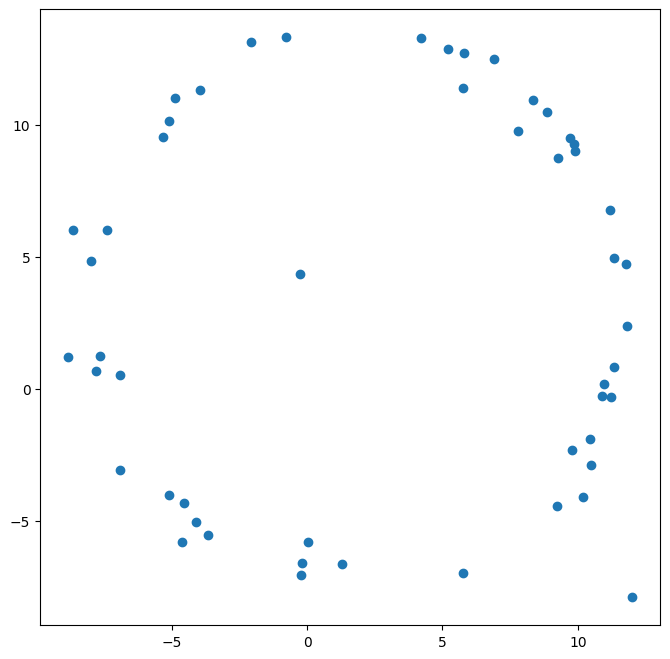

In [135]:
X_new = np.delete(X, inliers_line, axis=0)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_new[:, 0], X_new[:, 1], label='Remaining Points')

In [136]:
import cv2 as cv
import numpy as np

def compute_circle(p1, p2, p3):
    A = np.array([
        [p1[0], p1[1], 1],
        [p2[0], p2[1], 1],
        [p3[0], p3[1], 1]
    ])
    B = np.array([
        [-(p1[0]**2 + p1[1]**2)],
        [-(p2[0]**2 + p2[1]**2)],
        [-(p3[0]**2 + p3[1]**2)]
    ])
    C = np.linalg.det(A)
    if C == 0:
        return None  # Points are collinear

    D = np.linalg.det(np.hstack((B, A[:, 1:])))
    E = np.linalg.det(np.hstack((A[:, 0:1], B, A[:, 2:])))
    F = np.linalg.det(np.hstack((A[:, :2], B)))

    center_x = -D / (2 * C)
    center_y = -E / (2 * C)
    radius = np.sqrt((D**2 + E**2 - 4 * C * F) / (4 * C**2))

    return center_x, center_y, radius

def compute_circle2(p1, p2, p3):
    points = np.array([p1, p2, p3], dtype=np.float32)
    (center_x, center_y), radius = cv.minEnclosingCircle(points)
    return center_x, center_y, radius

def compute_error_circle(circle, point):
    center_x, center_y, radius = circle
    dist = np.abs(np.sqrt((point[0] - center_x)**2 + (point[1] - center_y)**2) - radius)
    return dist


In [137]:
def RANSAC_circle(X, N):
    for i in range(N): #number of iterations decided from the equation with 0.99 probability
        count = 0
        inliers = []
        idx = np.random.choice(X.shape[0], size=3, replace=False)
        circle = compute_circle2(X[idx[0]], X[idx[1]], X[idx[2]])
        for id, point in enumerate(X):
            error = compute_error_circle(circle, point)
            if error < 1.96 / 1.6: #threshold decided from the 1.96*sigma in line points
                inliers.append(id)
                count += 1
        if count >= 47: #if more than 47 points are inlier, we can stop
            best_circle = circle
            return best_circle, count, inliers, idx
        print(i, count)

Best circle found with center: 1.9991804361343384, 3.3444199562072754 and radius: 10.180354118347168 giving 47 inliers


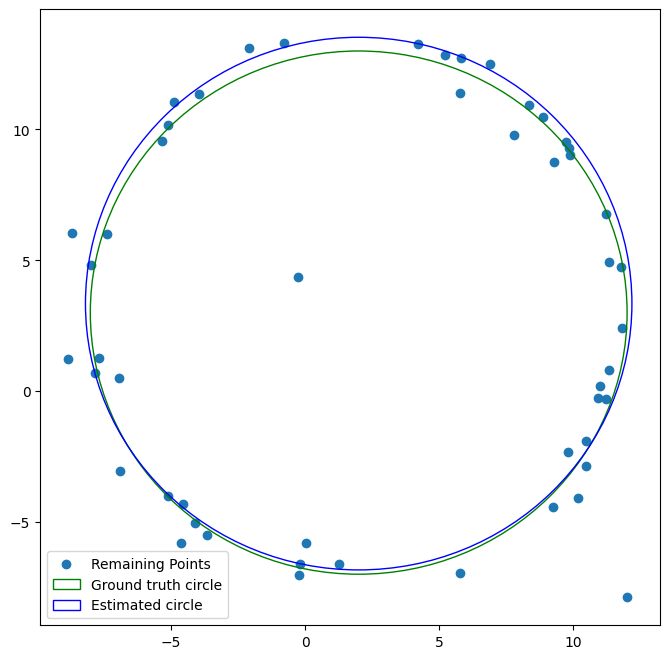

In [138]:
best_circle, count_circle, inliers_circle, idx_circle = RANSAC_circle(X_new, 35)
print(f"Best circle found with center: {best_circle[0]}, {best_circle[1]} and radius: {best_circle[2]} giving {count_circle} inliers")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_new[:, 0], X_new[:, 1], label='Remaining Points')
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
circle_est = plt.Circle((best_circle[0], best_circle[1]), best_circle[2], color='b', fill=False, label='Estimated circle')
ax.add_patch(circle_est)
plt.legend()
plt.show()

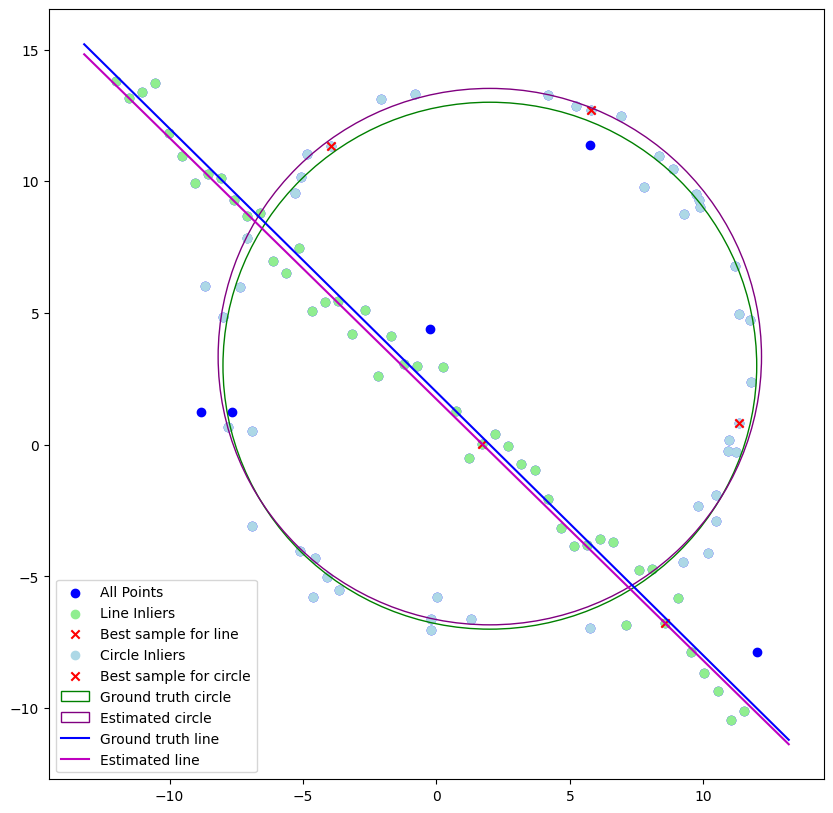

In [140]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(X[:, 0], X[:, 1], color='b', label='All Points')
ax.scatter(X[inliers_line, 0], X[inliers_line, 1], color='lightgreen', label='Line Inliers' )
ax.scatter(X[idx_line, 0], X[idx_line, 1], marker='x', color='r', label='Best sample for line')
ax.scatter(X[inliers_circle, 0], X[inliers_circle, 1], color='lightblue', label='Circle Inliers')
ax.scatter(X[idx_circle, 0], X[idx_circle, 1], marker='x', color='r', label='Best sample for circle')
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
circle_est = plt.Circle((best_circle[0], best_circle[1]), best_circle[2], color='purple', fill=False, label='Estimated circle')
ax.add_patch(circle_est)
ax.plot(x_, m * x_ + b, color='b', label='Ground truth line')
ax.plot(x_, -(best_line[0] * x_ + best_line[2]) / best_line[1], color='m', label='Estimated line')
plt.legend()
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Global list to store points
points = []

img = cv.imread('images/building.jpg')
img_display = img.copy()

# Destination points on the background (clockwise or counter-clockwise)
pts_dst = np.array([
    [242., 471.],
    [452., 594.],
    [473., 834.],
    [211., 756.]
], dtype=np.float32)

flag = cv.imread('images/nethu3.png')

h, w = flag.shape[:2]
pts_src = np.array([
    [0, 0],
    [w - 1, 0],
    [w - 1, h - 1],
    [0, h - 1]
], dtype=np.float32)


In [31]:
flag = cv.imread('images/nethu3.png')

h, w = flag.shape[:2]
pts_src = np.array([
    [0, 0],
    [w - 1, 0],
    [w - 1, h - 1],
    [0, h - 1]
], dtype=np.float32)

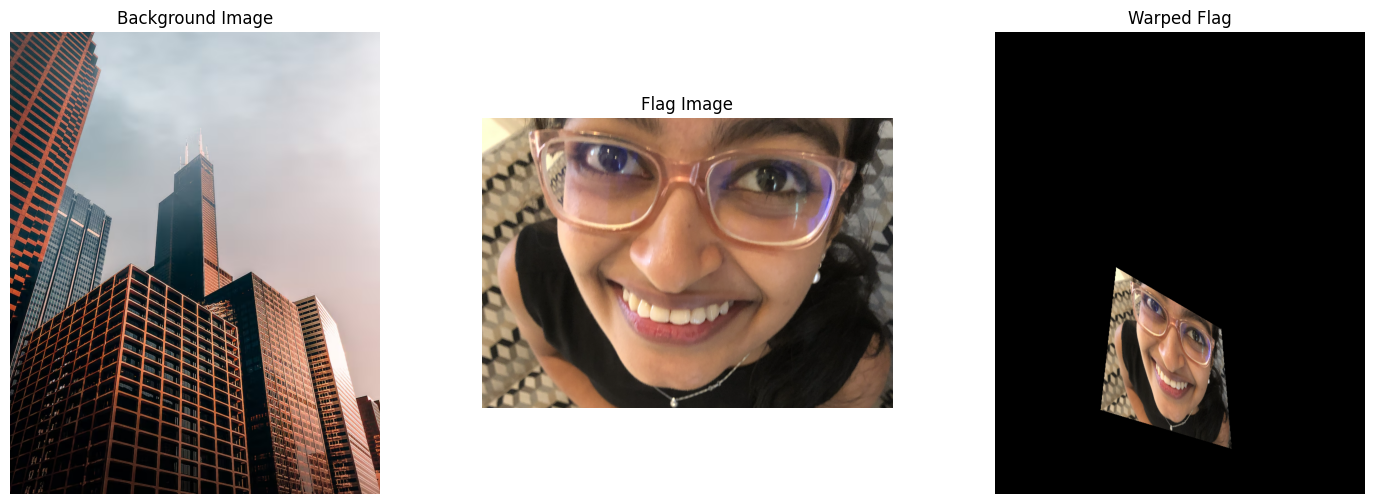

In [32]:
H = cv.getPerspectiveTransform(pts_src, pts_dst)

warped_flag = cv.warpPerspective(flag, H, (img.shape[1], img.shape[0]))

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[0].set_title('Background Image')
ax[0].axis('off')
ax[1].imshow(cv.cvtColor(flag, cv.COLOR_BGR2RGB))
ax[1].set_title('Flag Image')
ax[1].axis('off')
ax[2].imshow(cv.cvtColor(warped_flag, cv.COLOR_BGR2RGB))
ax[2].set_title('Warped Flag')
ax[2].axis('off')
plt.show()


(-0.5, 739.5, 924.5, -0.5)

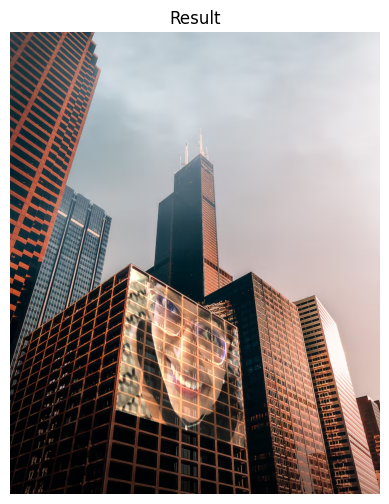

In [33]:
mask = np.zeros_like(img, dtype=np.uint8)
cv.fillConvexPoly(mask, pts_dst.astype(int), (255, 255, 255))

# Invert mask
mask_inv = cv.bitwise_not(mask)

# Black out region in background
bg_part = cv.bitwise_and(img, mask_inv)

# Add both
# result = cv.add(img, warped_flag)

# Average them
alpha = 0.5
beta = 1
gamma = 0  # scalar added to each sum
blended = cv.addWeighted(img, alpha, warped_flag, beta, gamma)

blended_area = cv.bitwise_and(blended, mask)

result = cv.add(bg_part, blended_area)

fig, ax = plt.subplots(1, 1, figsize=(24, 6))
ax.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
ax.set_title('Result')
ax.axis('off')


(< cv2.KeyPoint 0x104aa8540>, < cv2.KeyPoint 0x104aa96e0>, < cv2.KeyPoint 0x104971650>, < cv2.KeyPoint 0x14c28d5c0>, < cv2.KeyPoint 0x14c28d290>, < cv2.KeyPoint 0x14c28d530>, < cv2.KeyPoint 0x14c28d260>, < cv2.KeyPoint 0x14c28d590>, < cv2.KeyPoint 0x14c28d4d0>, < cv2.KeyPoint 0x14c28d650>, < cv2.KeyPoint 0x14c28c690>, < cv2.KeyPoint 0x14c28cf60>, < cv2.KeyPoint 0x14c28ced0>, < cv2.KeyPoint 0x14c28d620>, < cv2.KeyPoint 0x14c28d230>, < cv2.KeyPoint 0x14c28d6e0>, < cv2.KeyPoint 0x14c28c390>, < cv2.KeyPoint 0x1512678d0>, < cv2.KeyPoint 0x1512677e0>, < cv2.KeyPoint 0x151267870>, < cv2.KeyPoint 0x151266550>, < cv2.KeyPoint 0x151267450>, < cv2.KeyPoint 0x151267bd0>, < cv2.KeyPoint 0x151266280>, < cv2.KeyPoint 0x151266a30>, < cv2.KeyPoint 0x151267cf0>, < cv2.KeyPoint 0x151266940>, < cv2.KeyPoint 0x151266df0>, < cv2.KeyPoint 0x151266d90>, < cv2.KeyPoint 0x151267a80>, < cv2.KeyPoint 0x151267210>, < cv2.KeyPoint 0x151267240>, < cv2.KeyPoint 0x151267270>, < cv2.KeyPoint 0x1512663d0>, < cv2.KeyPoin

(-0.5, 1599.5, 639.5, -0.5)

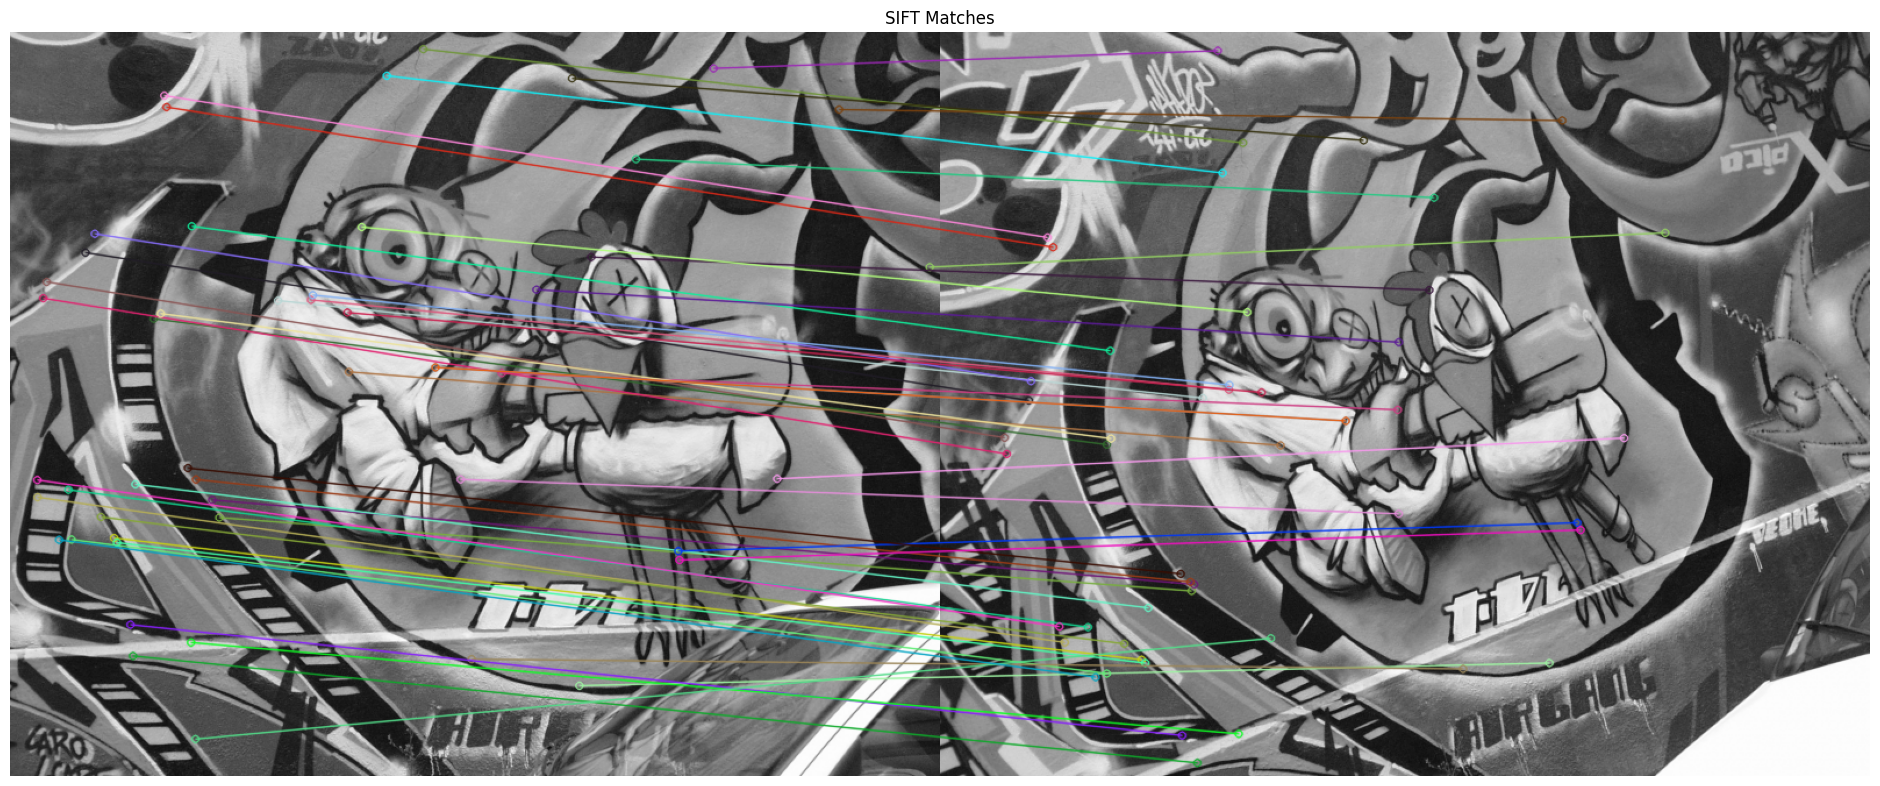

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the two images
img1 = cv.imread('images/img1.ppm', cv.IMREAD_GRAYSCALE)  # Query image
img2 = cv.imread('images/img2.ppm', cv.IMREAD_GRAYSCALE)  # Train image


# Create SIFT detector
sift = cv.SIFT_create()

# Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print(kp1, des1)

# Create BFMatcher
bf = cv.BFMatcher(cv.NORM_L2, crossCheck=True)

# Match descriptors
matches = bf.match(des1, des2)

# Sort matches by distance (lower distance = better match)
matches = sorted(matches, key=lambda x: x.distance)

# Draw the top 50 matches
matched_img = cv.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matched image
fig, ax = plt.subplots(1, 1, figsize=(24, 12))
ax.imshow(cv.cvtColor(matched_img, cv.COLOR_BGR2RGB))
ax.set_title('SIFT Matches')
ax.axis('off')  
